# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

*The objective of this experiment is to observe and if there is a difference between percentage scores based on the three different teaching methods*

**Question 2.** Specify the outcome variable

*The outcome variable is the percentage scores of the 50-question quiz, and this variable is a discrete, quantitative variable.*

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

*The independent variable is the type of teaching method. This is a categorical variable with three levels: direct instruction, inquiry-based learning, and collaborative learning. The blocking factor is the given prior knowledge for each student, separated into two categories: "High" and "Low". A possible lurking variable would include the age, which is a quantitative variable.*

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

*A randomized block design would be appropriate because the experimental units (aka the students) are not homogeneous with respect to a particular variable (the prior knowledge of a student). A completely randomized design would not be appropriate because it of the lack of homogeniety among the experimental units. This would create extra variation in our analysis.*

**Question 5.** State the null and alternative hypotheses for this experiment.

*H0: The mean percentage score among the different teaching methods are the same.*

*HA: At least one mean percentage score among the different teaching methods is significantly different.*


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

*Based on the summary statistics and data visualizations, the results of the analyses show strong support toward the alternative hypothesis*

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Data Science Teaching Method.xlsx to Data Science Teaching Method.xlsx


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114


Text(0, 0.5, 'Score')

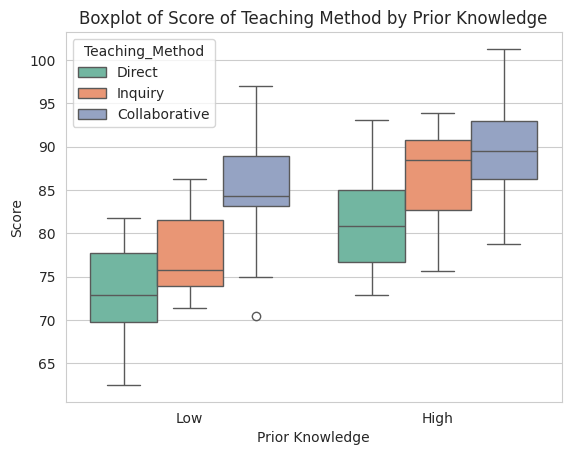

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

teaching = pd.read_excel('Data Science Teaching Method.xlsx')

print(teaching.info())

sum_stats = teaching.groupby(['Prior_Knowledge', 'Teaching_Method'])['Score'].agg(['mean', 'std'])
print(sum_stats)


#Specify order

knowledge_order = ['Low', 'High']

teaching['Prior_Knowledge'] = pd.Categorical(teaching['Prior_Knowledge'], categories=knowledge_order, ordered=True)

## Step 2: Create the boxplot using seaborn.
## We use the `order` and `hue_order` parameters to ensure the correct order.

sns.set_style("whitegrid")

sns.boxplot(
    data = teaching,
    x = 'Prior_Knowledge',
    y = 'Score',
    hue = 'Teaching_Method',
    palette = 'Set2'
)

plt.title('Boxplot of Score of Teaching Method by Prior Knowledge')
plt.xlabel('Prior Knowledge')
plt.ylabel('Score')

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

*Based on the visual & testing method results, the results support the assumption of normality. The p-value is greater than 0.05, which means that we fail to reject the null hypothesis that the residuals are normally distributed. Also, the QQ plot shows that the dots, for the most part, all fall near the diagnol line, further confirming assumption of normality.*

In [6]:
teaching.rename(columns={"Teaching Method": "Teaching_Method","Prior Knowledge": "Prior_Knowledge"}, inplace=True)


ex_mod = ols("Score ~ Teaching_Method + Prior_Knowledge", data=teaching).fit()

# ANOVA table
ex_tab = sm.stats.anova_lm(ex_mod,typ=3)


## Add Significance Column ##
ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")


# Print only Teaching and Knowledge rows
print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


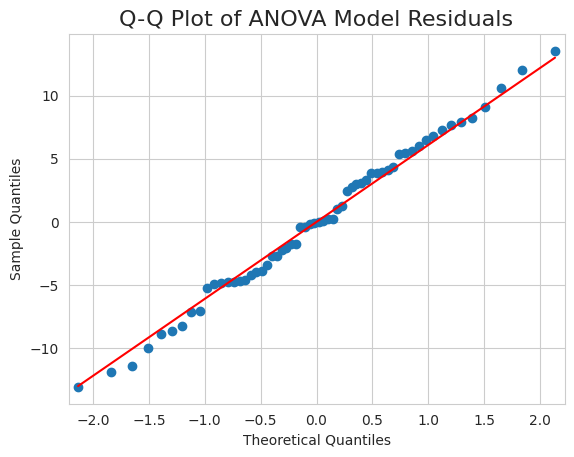

Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed (fail to reject H0).


In [7]:
## Import scipy ##
import scipy.stats as stats

## Extract Model Residuals ##
ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

*Based on the fact that there are no values greater than 3 or less than -3, and based on the fact that our p-value is much greater than 0.05, this means that the there is no heteroscedascity detected, and that we fail to reject the hull hypothesis. This also means that constant variance can be assumed.*

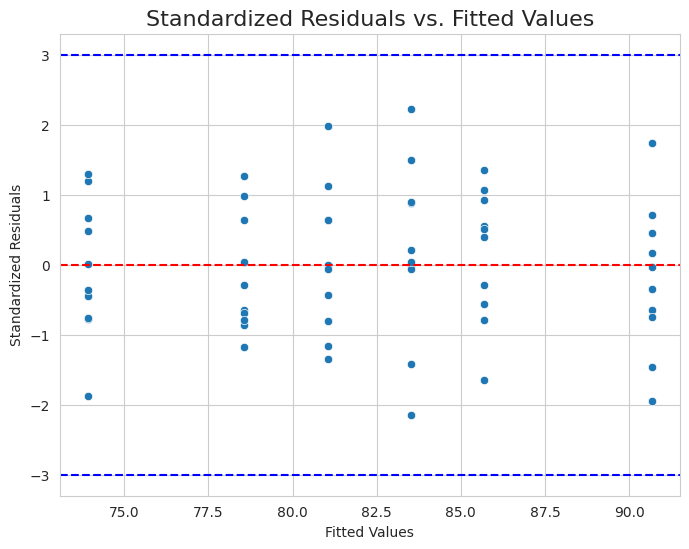

F-statistic: 0.7579465871345092
F p-value: 0.5224437459616427
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [8]:
## Obtain Standardized Residuals ##
standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()


## B-P Test ##
## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan


## Run B-P Test ##
bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)


## Extract F-statistic ##
f_statistic = bp_test[2]


## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Question 2.** Specify the outcome variable

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.